# Cetuximab Variant — Heavy & Light Chain Sequence Comparison

Compare the **heavy (VH)** and **light (VL)** variable domains across the wild type and the designs.

| Label | Source | Notes |
|-------|--------|-------|
| `WT_1YY9` | `data/1YY9.pdb` — chain **D** (heavy), chain **C** (light) | Crystallised Fab (IMC-11F8 / Cetuximab-class). Trimmed to the Fv region. |
| `Cetuximab` | `data/cetuximab_variants.fasta` | Parent design reference (VH 119 aa / VL 106 aa). |
| `ConvergeAB` | `data/cetuximab_variants.fasta` | Zero-shot pLM design — 6 engineered mutations. |

**Method.** 1YY9 chains include the constant CH1/CL domains (220 / 211 aa). We trim each to its
variable domain by local alignment to the design reference. Comparison is then done by **gap-aware
pairwise alignment** (BLOSUM62) — necessary because the WT light chain carries a single-residue
indel (`DILL…` vs design `DIL…`), which a naive position-by-position diff would frameshift.
Differences are reported **relative to `WT_1YY9`** in WT residue numbering, with CDRs (located by
motif) shaded.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import biotite.structure as struc
import biotite.structure.io.pdb as pdb
from Bio import SeqIO, Align
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

DATA = pathlib.Path("data")

THREE2ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q",
    "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S", "THR": "T", "TRP": "W",
    "TYR": "Y", "VAL": "V",
}


def chain_sequence(atoms, chain):
    """One-letter sequence of a chain, residues in structural order."""
    sub = atoms[atoms.chain_id == chain]
    seq, seen = [], set()
    for res_name, res_id in zip(sub.res_name, sub.res_id):
        if res_id not in seen:
            seen.add(res_id)
            seq.append(THREE2ONE.get(res_name, "X"))
    return "".join(seq)


# ── Wild type: extract heavy (D) and light (C) chains from 1YY9 ──
pdb_file = pdb.PDBFile.read(str(DATA / "1YY9.pdb"))
atoms = pdb.get_structure(pdb_file, model=1)
atoms = atoms[struc.filter_canonical_amino_acids(atoms)]

wt_heavy_full = chain_sequence(atoms, "D")
wt_light_full = chain_sequence(atoms, "C")
print(f"1YY9 chain D (heavy) full chain : {len(wt_heavy_full)} aa")
print(f"1YY9 chain C (light) full chain : {len(wt_light_full)} aa")

1YY9 chain D (heavy) full chain : 220 aa
1YY9 chain C (light) full chain : 211 aa


In [2]:
# ── Load designs from FASTA ──
designs = {r.id: str(r.seq) for r in SeqIO.parse(str(DATA / "cetuximab_variants.fasta"), "fasta")}
for name, seq in designs.items():
    print(f"{name:16s} {len(seq):3d} aa")

# ── Aligners ──
_local = Align.PairwiseAligner()
_local.mode = "local"
_local.substitution_matrix = substitution_matrices.load("BLOSUM62")
_local.open_gap_score = -10
_local.extend_gap_score = -0.5

_global = Align.PairwiseAligner()
_global.mode = "global"
_global.substitution_matrix = substitution_matrices.load("BLOSUM62")
_global.open_gap_score = -10
_global.extend_gap_score = -0.5
# Free end gaps so a terminal indel (WT light N-terminus) is not over-penalized.
# (target_end_gap_score/query_end_gap_score were renamed in newer Biopython;
#  suppress the harmless deprecation notice.)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _global.target_end_gap_score = 0.0
    _global.query_end_gap_score = 0.0


def trim_to_fv(full_seq, reference):
    """Return the slice of `full_seq` spanning its local alignment to `reference` (the Fv)."""
    aln = _local.align(full_seq, reference)[0]
    return full_seq[aln.aligned[0][0][0]:aln.aligned[0][-1][1]]


wt_heavy = trim_to_fv(wt_heavy_full, designs["Cetuximab_VH"])
wt_light = trim_to_fv(wt_light_full, designs["Cetuximab_VL"])
print(f"\nWT heavy Fv : {len(wt_heavy)} aa")
print(f"WT light Fv : {len(wt_light)} aa  (note: WT light carries a 1-residue indel vs design)")

Cetuximab_VH     119 aa
Cetuximab_VL     106 aa
ConvergeAB_VH    119 aa
ConvergeAB_VL    106 aa
Vh_hu225         119 aa
Vl_hu225         107 aa

WT heavy Fv : 119 aa
WT light Fv : 105 aa  (note: WT light carries a 1-residue indel vs design)


In [3]:
# ── Gap-aware comparison helpers ──
CDR_MOTIFS = {
    "VH": {"CDR-H1": "GFSLTNYG", "CDR-H2": "IWSGGN", "CDR-H3": "ARALTYYDYEFAY"},
    "VL": {"CDR-L1": "RASQSIGTN", "CDR-L2": "YASESIS", "CDR-L3": "QQNNN"},
}


def regap(seq, template_gapped):
    """Lay `seq` onto the gap pattern of `template_gapped` (same ungapped length)."""
    out, k = [], 0
    for ch in template_gapped:
        if ch == "-":
            out.append("-")
        else:
            out.append(seq[k]); k += 1
    return "".join(out)


def build_msa(ref_label, ref_seq, variants):
    """Reference-anchored (star) MSA. Each variant is globally aligned to ref_seq
    independently, then the alignments are merged into a single coordinate frame.
    Unlike a colinear regap, this handles variants with their own indels and
    differing lengths (e.g. a humanized variant with a distinct N-terminus).
    The reference row's non-gap characters are exactly `ref_seq` in order, so
    downstream WT-position numbering still holds. Returns dict label->gapped row."""
    N = len(ref_seq)
    # Per variant: assigned[i] = residue at ref position i ('-' = deletion);
    #              ins[s]      = residues inserted *before* ref position s
    #                           (ins[N] = inserted after the last ref residue).
    per_var = {}
    for lbl, seq in variants.items():
        aln = _global.align(ref_seq, seq)[0]
        ref_g, var_g = aln[0], aln[1]
        assigned = ["-"] * N
        ins = [[] for _ in range(N + 1)]
        i = 0
        for rc, vc in zip(ref_g, var_g):
            if rc != "-":
                assigned[i] = vc
                i += 1
            elif vc != "-":
                ins[i].append(vc)
        per_var[lbl] = (assigned, ins)

    # Width of each insertion slot = max insertion across all variants there.
    ins_width = [0] * (N + 1)
    for assigned, ins in per_var.values():
        for s in range(N + 1):
            ins_width[s] = max(ins_width[s], len(ins[s]))

    def render(get_ins, get_ref):
        row = []
        for s in range(N + 1):
            for k in range(ins_width[s]):
                row.append(get_ins(s, k))
            if s < N:
                row.append(get_ref(s))
        return "".join(row)

    msa = {ref_label: render(lambda s, k: "-", lambda i: ref_seq[i])}
    for lbl, (assigned, ins) in per_var.items():
        msa[lbl] = render(
            lambda s, k, ins=ins: ins[s][k] if k < len(ins[s]) else "-",
            lambda i, assigned=assigned: assigned[i],
        )
    return msa


def cdr_columns(ref_gapped, chain_type):
    ungapped = ref_gapped.replace("-", "")
    idx_to_col, k = {}, 0
    for c, ch in enumerate(ref_gapped):
        if ch != "-":
            idx_to_col[k] = c; k += 1
    spans = {}
    for name, motif in CDR_MOTIFS[chain_type].items():
        i = ungapped.find(motif)
        if i >= 0:
            spans[name] = (idx_to_col[i], idx_to_col[i + len(motif) - 1] + 1)
    return spans


def mutation_table(msa, ref_label, chain_type):
    """Per-column differences of each variant vs the reference row, in WT numbering."""
    ref_g = msa[ref_label]
    ungapped = ref_g.replace("-", "")
    cdrs_ungapped = {}
    for name, motif in CDR_MOTIFS[chain_type].items():
        i = ungapped.find(motif)
        if i >= 0:
            cdrs_ungapped[name] = (i, i + len(motif))

    def region(refpos0):  # refpos0 = 0-indexed ungapped ref position
        for name, (s, e) in cdrs_ungapped.items():
            if s <= refpos0 < e:
                return name
        return "FR"

    rows = []
    for lbl, gseq in msa.items():
        if lbl == ref_label:
            continue
        refpos = 0
        for c, rc in enumerate(ref_g):
            vc = gseq[c]
            if rc != "-":
                if vc != rc:
                    kind = "sub" if vc != "-" else "del"
                    rows.append(dict(variant=lbl, wt_pos=refpos + 1, wt=rc,
                                     mut=vc, kind=kind, region=region(refpos)))
                refpos += 1
            else:  # insertion in variant relative to WT
                if vc != "-":
                    rows.append(dict(variant=lbl, wt_pos=refpos, wt="-",
                                     mut=vc, kind="ins", region="FR"))
    return pd.DataFrame(rows)


def pct_identity(a, b):
    aln = _global.align(a, b)[0]
    ga, gb = aln[0], aln[1]
    matches = sum(x == y and x != "-" for x, y in zip(ga, gb))
    return round(100.0 * matches / len(ga), 1)


def identity_matrix(seqs):
    labels = list(seqs)
    M = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for a in labels:
        for b in labels:
            M.loc[a, b] = pct_identity(seqs[a], seqs[b])
    return M

## Heavy chain (VH)

In [4]:
heavy = {"WT_1YY9": wt_heavy,
         "Cetuximab": designs["Cetuximab_VH"],
         "ConvergeAB": designs["ConvergeAB_VH"],
         "hu225": designs["Vh_hu225"]}

msa_h = build_msa("WT_1YY9", heavy["WT_1YY9"],
                  {k: v for k, v in heavy.items() if k != "WT_1YY9"})
muts_h = mutation_table(msa_h, "WT_1YY9", "VH")

print(f"Heavy-chain differences vs WT_1YY9 ({len(muts_h)} total):")
print(muts_h.to_string(index=False))
print("\n% identity matrix (VH):")
print(identity_matrix(heavy).to_string())

Heavy-chain differences vs WT_1YY9 (40 total):
   variant  wt_pos wt mut kind region
 Cetuximab       5  K   Q  sub     FR
 Cetuximab      57  T   I  sub     FR
 Cetuximab      70  N   S  sub     FR
 Cetuximab      71  K   R  sub     FR
 Cetuximab      73  N   T  sub     FR
 Cetuximab      87  S   T  sub     FR
 Cetuximab      88  N   D  sub     FR
 Cetuximab     119  A   S  sub     FR
ConvergeAB       5  K   Q  sub     FR
ConvergeAB      57  T   I  sub     FR
ConvergeAB      61  T   A  sub     FR
ConvergeAB      70  N   S  sub     FR
ConvergeAB      71  K   R  sub     FR
ConvergeAB      73  N   T  sub     FR
ConvergeAB      87  S   A  sub     FR
ConvergeAB      88  N   D  sub     FR
ConvergeAB     119  A   S  sub     FR
     hu225       1  Q   E  sub     FR
     hu225       5  K   V  sub     FR
     hu225       6  Q   E  sub     FR
     hu225       9  P   G  sub     FR
     hu225      15  S   G  sub     FR
     hu225      16  Q   G  sub     FR
     hu225      19  S   R  sub     FR
   

## Light chain (VL)

In [5]:
light = {"WT_1YY9": wt_light,
         "Cetuximab": designs["Cetuximab_VL"],
         "ConvergeAB": designs["ConvergeAB_VL"],
         "hu225": designs["Vl_hu225"]}

msa_l = build_msa("WT_1YY9", light["WT_1YY9"],
                  {k: v for k, v in light.items() if k != "WT_1YY9"})
muts_l = mutation_table(msa_l, "WT_1YY9", "VL")

print(f"Light-chain differences vs WT_1YY9 ({len(muts_l)} total):")
print(muts_l.to_string(index=False))
print("\n% identity matrix (VL):")
print(identity_matrix(light).to_string())

Light-chain differences vs WT_1YY9 (38 total):
   variant  wt_pos wt mut kind region
 Cetuximab       0  -   D  ins     FR
 Cetuximab       1  L   I  sub     FR
 Cetuximab      43  R   K  sub     FR
 Cetuximab      47  K   R  sub     FR
 Cetuximab      77  E   D  sub     FR
 Cetuximab      78  S   P  sub     FR
ConvergeAB       0  -   D  ins     FR
ConvergeAB       1  L   I  sub     FR
ConvergeAB       8  I   A  sub     FR
ConvergeAB      31  I   D  sub     FR
ConvergeAB      43  R   K  sub     FR
ConvergeAB      47  K   R  sub     FR
ConvergeAB      77  E   D  sub     FR
ConvergeAB      78  S   P  sub     FR
ConvergeAB      92  W   A  sub     FR
     hu225       0  -   D  ins     FR
     hu225       0  -   I  ins     FR
     hu225       7  V   G  sub     FR
     hu225       8  I   T  sub     FR
     hu225      11  V   L  sub     FR
     hu225      17  V   A  sub     FR
     hu225      18  S   T  sub     FR
     hu225      19  F   L  sub     FR
     hu225      37  R   K  sub     FR
   

## Alignment visualization

Each row is a sequence (gap-aware MSA); columns are alignment positions. Cells differing from
`WT_1YY9` (top row) are highlighted **red**; CDR regions are shaded **yellow**. Gaps shown as `-`.

Saved data/sequence_comparison.png


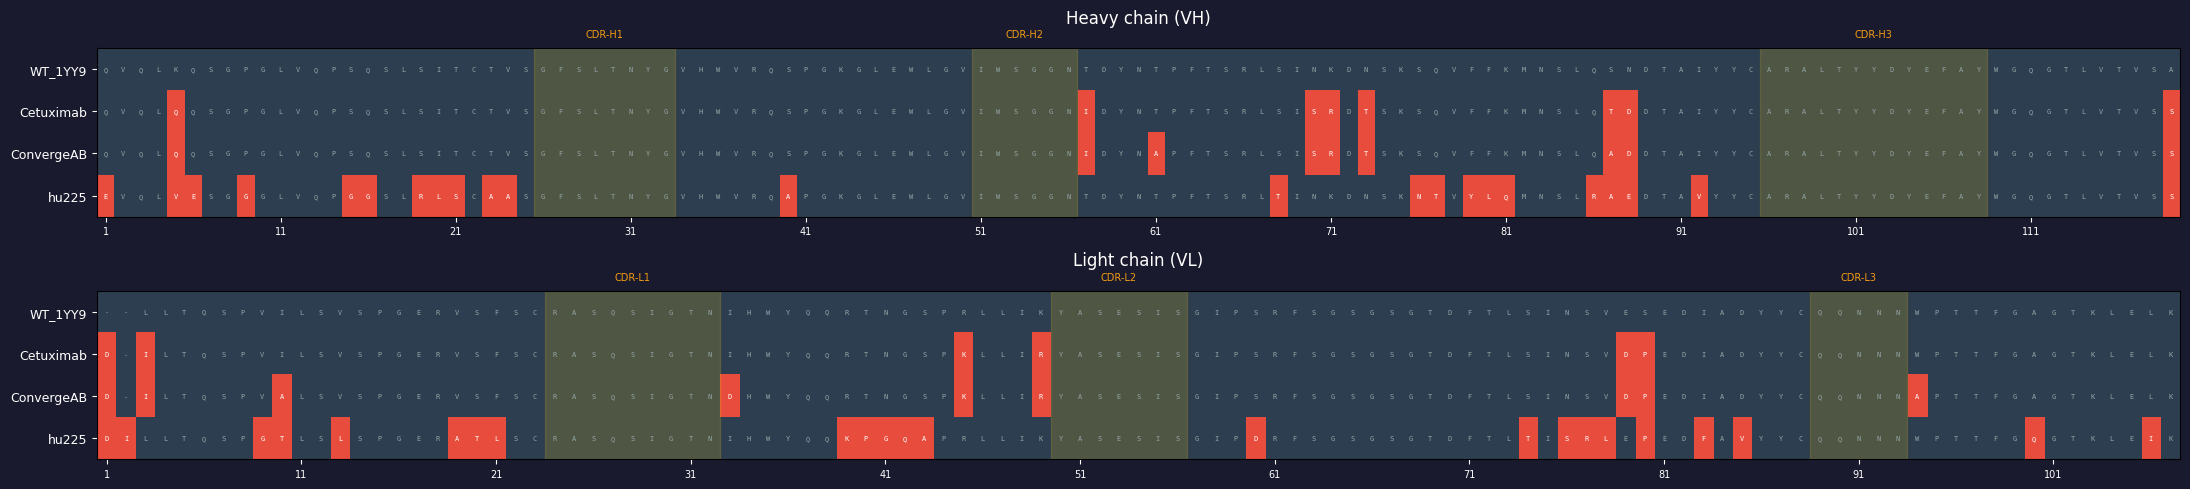

In [6]:
def plot_msa(msa, ref_label, cdrs, title, ax):
    labels = list(msa)
    ref = msa[ref_label]
    L = len(ref)

    mism = np.zeros((len(labels), L))
    for i, lbl in enumerate(labels):
        s = msa[lbl]
        for j in range(L):
            if s[j] != ref[j]:
                mism[i, j] = 1

    ax.imshow(mism, aspect="auto", cmap=ListedColormap(["#2c3e50", "#e74c3c"]),
              interpolation="nearest", vmin=0, vmax=1)
    for i, lbl in enumerate(labels):
        s = msa[lbl]
        for j in range(L):
            ax.text(j, i, s[j], ha="center", va="center", fontsize=5,
                    fontfamily="monospace", color="white" if mism[i, j] else "#95a5a6")
    for name, (s, e) in cdrs.items():
        ax.axvspan(s - 0.5, e - 0.5, color="#f1c40f", alpha=0.18, zorder=0)
        ax.text((s + e) / 2 - 0.5, -0.75, name, ha="center", fontsize=7, color="#f39c12")

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9, color="white")
    ax.set_xticks(range(0, L, 10))
    ax.set_xticklabels(range(1, L + 1, 10), fontsize=7, color="white")
    ax.set_xlim(-0.5, L - 0.5)
    ax.set_title(title, color="white", fontsize=12, pad=18)
    ax.tick_params(colors="white")


fig, axes = plt.subplots(2, 1, figsize=(22, 5))
fig.patch.set_facecolor("#1a1a2e")
for ax in axes:
    ax.set_facecolor("#1a1a2e")

plot_msa(msa_h, "WT_1YY9", cdr_columns(msa_h["WT_1YY9"], "VH"), "Heavy chain (VH)", axes[0])
plot_msa(msa_l, "WT_1YY9", cdr_columns(msa_l["WT_1YY9"], "VL"), "Light chain (VL)", axes[1])

plt.tight_layout()
out = DATA / "sequence_comparison.png"
fig.savefig(out, dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## Identity of switched positions

For every position that differs from `WT_1YY9`, show **which amino acid it switched to** and
its physicochemical class. Marker shape encodes the change type (■ substitution, ▲ insertion,
▼ deletion); the letter is the introduced residue. The bottom panel summarises, per variant,
*which kinds of residues* each design introduces — e.g. ConvergeAB's bias toward small
(Ala / `Special`) and acidic (Asp / `Negative`) substitutions.

Saved data/switched_identity.png


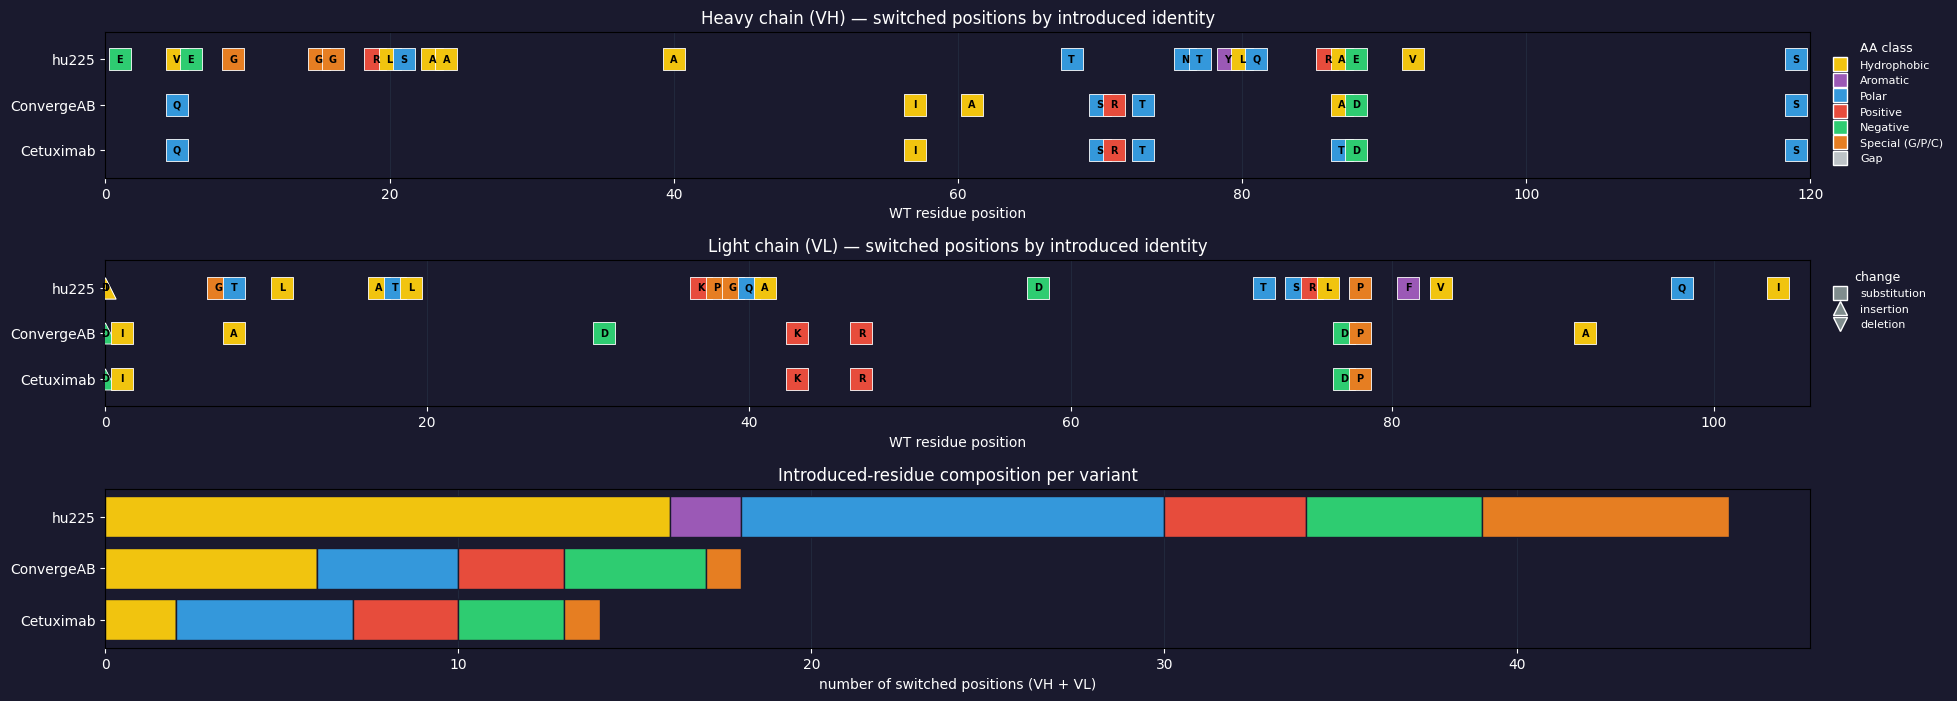

In [7]:
# ── Amino-acid physicochemical classes ──
AA_CLASS = {}
for _aa in "AVLIM": AA_CLASS[_aa] = "Hydrophobic"
for _aa in "FWY":   AA_CLASS[_aa] = "Aromatic"
for _aa in "STNQ":  AA_CLASS[_aa] = "Polar"
for _aa in "KRH":   AA_CLASS[_aa] = "Positive"
for _aa in "DE":    AA_CLASS[_aa] = "Negative"
for _aa in "GPC":   AA_CLASS[_aa] = "Special (G/P/C)"

CLASS_COLOR = {
    "Hydrophobic":     "#f1c40f",
    "Aromatic":        "#9b59b6",
    "Polar":           "#3498db",
    "Positive":        "#e74c3c",
    "Negative":        "#2ecc71",
    "Special (G/P/C)": "#e67e22",
    "Gap":             "#bdc3c7",
}
CLASS_ORDER = ["Hydrophobic", "Aromatic", "Polar", "Positive", "Negative",
               "Special (G/P/C)", "Gap"]


def aa_class(aa):
    return AA_CLASS.get(aa, "Gap")


def plot_switch_map(muts, title, ref_len, ax):
    variants = list(dict.fromkeys(muts["variant"]))
    ymap = {v: i for i, v in enumerate(variants)}
    shape = {"sub": "s", "ins": "^", "del": "v"}
    for _, r in muts.iterrows():
        new = r["mut"]
        cls = aa_class(new)
        ax.scatter(r["wt_pos"], ymap[r["variant"]], s=230, zorder=3,
                   c=CLASS_COLOR[cls], marker=shape.get(r["kind"], "s"),
                   edgecolors="white", linewidths=0.6)
        ax.text(r["wt_pos"], ymap[r["variant"]], new if new != "-" else "Δ",
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="black", zorder=4)
    ax.set_yticks(range(len(variants)))
    ax.set_yticklabels(variants, color="white")
    ax.set_ylim(-0.6, len(variants) - 0.4)
    ax.set_xlim(0, ref_len + 1)
    ax.set_xlabel("WT residue position", color="white")
    ax.set_title(title, color="white", fontsize=12)
    ax.tick_params(colors="white")
    ax.grid(axis="x", color="#34495e", alpha=0.3, zorder=0)


# Combine both chains and classify the introduced residue
all_muts = pd.concat([muts_h.assign(chain="VH"), muts_l.assign(chain="VL")],
                     ignore_index=True)
all_muts["new_class"] = all_muts["mut"].map(aa_class)

fig = plt.figure(figsize=(22, 8))
fig.patch.set_facecolor("#1a1a2e")
gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.1, 1.2], hspace=0.55)
ax_h = fig.add_subplot(gs[0]); ax_l = fig.add_subplot(gs[1]); ax_c = fig.add_subplot(gs[2])
for ax in (ax_h, ax_l, ax_c):
    ax.set_facecolor("#1a1a2e")

plot_switch_map(muts_h, "Heavy chain (VH) — switched positions by introduced identity",
                len(wt_heavy), ax_h)
plot_switch_map(muts_l, "Light chain (VL) — switched positions by introduced identity",
                len(wt_light), ax_l)

# ── Composition panel: which identities each variant introduces ──
comp = (all_muts.groupby(["variant", "new_class"]).size()
        .unstack(fill_value=0).reindex(columns=CLASS_ORDER, fill_value=0))
variants = list(comp.index)
left = np.zeros(len(variants))
for cls in CLASS_ORDER:
    if comp[cls].sum() == 0:
        continue
    ax_c.barh(variants, comp[cls].values, left=left, color=CLASS_COLOR[cls],
              edgecolor="#1a1a2e", label=cls)
    left += comp[cls].values
ax_c.set_xlabel("number of switched positions (VH + VL)", color="white")
ax_c.set_title("Introduced-residue composition per variant", color="white", fontsize=12)
ax_c.tick_params(colors="white")
ax_c.set_axisbelow(True)
ax_c.grid(axis="x", color="#34495e", alpha=0.3)

# Shared legends: AA class (colour) + change type (marker)
from matplotlib.lines import Line2D
class_handles = [Line2D([0], [0], marker="s", linestyle="", markersize=10,
                        markerfacecolor=CLASS_COLOR[c], markeredgecolor="white", label=c)
                 for c in CLASS_ORDER]
shape_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor="#7f8c8d",
           markeredgecolor="white", label="substitution"),
    Line2D([0], [0], marker="^", linestyle="", markersize=10, markerfacecolor="#7f8c8d",
           markeredgecolor="white", label="insertion"),
    Line2D([0], [0], marker="v", linestyle="", markersize=10, markerfacecolor="#7f8c8d",
           markeredgecolor="white", label="deletion"),
]
leg1 = ax_h.legend(handles=class_handles, loc="upper left", bbox_to_anchor=(1.005, 1.0),
                   fontsize=8, frameon=False, labelcolor="white", title="AA class",
                   title_fontsize=9)
leg1.get_title().set_color("white")
leg2 = ax_l.legend(handles=shape_handles, loc="upper left", bbox_to_anchor=(1.005, 1.0),
                   fontsize=8, frameon=False, labelcolor="white", title="change",
                   title_fontsize=9)
leg2.get_title().set_color("white")

out = DATA / "switched_identity.png"
fig.savefig(out, dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## Summary

- **`WT_1YY9` vs `Cetuximab`** — the crystallised 1YY9 Fab (IMC-11F8 class) differs from the
  Cetuximab parent reference at several framework positions plus a single-residue indel in the
  light-chain N-terminus. These are *not* engineered mutations — they reflect the difference
  between the deposited structure and the design parent sequence.
- **`Cetuximab` vs `ConvergeAB`** — the 6 engineered mutations (VH T61A, S87A, N88D · VL V9A,
  N32D, N93A) that drive the affinity/developability gain. They sit in framework / CDR-flanking
  positions; the primary binding loop CDR-H3 (`ARALTYYDYEFAY`) is fully preserved.
- Rendered alignment: `data/sequence_comparison.png`.

> All differences (substitutions, insertions, deletions) are enumerated in the mutation tables
> above with `kind` and CDR/FR `region` annotation.